Loading the data from the huggingface

In [1]:
from datasets import load_dataset, load_from_disk

ds_v2 = load_from_disk("/scratch/project_465001820/Spatialformer/cache/xenium_5k_pandavid_dataset_v2")

/scratch/project_465001820/miniconda3/envs/spatialformer/lib/python3.8/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/project_465001820/miniconda3/envs/spatialformer/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Statistic the number of gene and total count for each cell

In [6]:
def compute_metrics(batch):
    # Retrieve the list of expression vectors
    Full_Tokens = batch["Full_Tokens"]
    
    # METHOD: List Comprehension (Safest)
    # We process each cell individualy. This avoids the AxisError 
    # even if NumPy cannot form a perfect 2D matrix.
    
    # 1. Count non-zeros (expressed genes)
    n_expressed = [len(Full_Token)-4 for Full_Token in Full_Tokens]
    
    # 2. Sum totals (if you still need this)
    # total_counts = [np.sum(cell) for cell in expression_data]
    
    return {
        "n_expressed": n_expressed,

    }


# Apply the map function
# Note: Ensure your machine actually has enough RAM to support 256 processes, 
# otherwise this might crash.
processed_ds = ds_v2.map(
    compute_metrics, 
    batched=True, 
    batch_size=10000,
    num_proc=256
)

# Extract the final result as a list of dictionaries/tuples
# Each item corresponds to a cell
final_results = [
    ne
    for ne in processed_ds["n_expressed"]
]

Map (num_proc=256): 100%|██████████| 11625356/11625356 [11:34<00:00, 16733.47 examples/s]


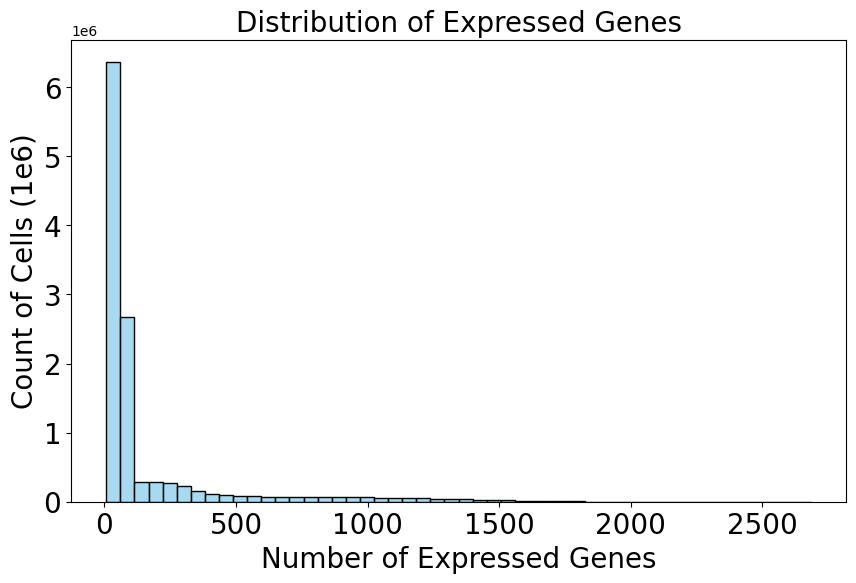

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get the data
data = final_results

# 2. Setup Figure
plt.figure(figsize=(10, 6))

# 3. Create the Histogram (Bar plot of distribution)
# bins=50: Groups the data into 50 bars. Adjust this number if you want thinner/thicker bars.
# kde=False: Ensures we only see bars, no density line.
sns.histplot(data, bins=50, color="skyblue", edgecolor="black")

# 4. Labels (I increased these slightly to match the larger ticks)
plt.title("Distribution of Expressed Genes", fontsize=20)
plt.xlabel("Number of Expressed Genes", fontsize=20)
plt.ylabel("Count of Cells (1e6)", fontsize=20)

# 5. Tick Labels (The numbers on the axis)
plt.xticks(fontsize=20)  # Sets the X-axis numbers size
plt.yticks(fontsize=20)  # Sets the Y-axis numbers size
plt.savefig("./barplot.png", dpi=300)
plt.show()